In [1]:
import sys
sys.path.insert(0, r'E:\regime_factor_model\libs')
print("Ready to build! ")

Ready to build! 


In [2]:
import sys
sys.path.insert(0, r'E:\regime_factor_model\libs')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import pandas_datareader as pdr
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully")
print(f"Date: {datetime.today().strftime('%Y-%m-%d')}")

Libraries loaded successfully
Date: 2026-04-23


In [4]:
import requests

# Download S&P 500 tickers using requests with a browser header
url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
headers = {'User-Agent': 'Mozilla/5.0'}
response = requests.get(url, headers=headers)

sp500_table = pd.read_html(response.text)
sp500_tickers = sp500_table[0]['Symbol'].tolist()
sp500_tickers = [ticker.replace('.', '-') for ticker in sp500_tickers]

print(f"Total S&P 500 stocks found: {len(sp500_tickers)}")
print(f"First 10 tickers: {sp500_tickers[:10]}")

Total S&P 500 stocks found: 503
First 10 tickers: ['MMM', 'AOS', 'ABT', 'ABBV', 'ACN', 'ADBE', 'AMD', 'AES', 'AFL', 'A']


In [5]:
# Download 20 years of daily price data for all S&P 500 stocks
start_date = '2004-01-01'
end_date = '2024-12-31'

print("Downloading S&P 500 data... this will take 3-5 minutes")

raw_data = yf.download(
    tickers=sp500_tickers,
    start=start_date,
    end=end_date,
    group_by='ticker',
    auto_adjust=True,
    threads=True
)

print(f"Download complete!")
print(f"Shape: {raw_data.shape}")
print(f"Date range: {raw_data.index[0]} to {raw_data.index[-1]}")

[****************      34%                       ]  171 of 503 completed$Q: possibly delisted; no price data found  (1d 2004-01-01 -> 2024-12-31) (Yahoo error = "Data doesn't exist for startDate = 1072933200, endDate = 1735621200")
[**********************65%******                 ]  329 of 503 completed$SNDK: possibly delisted; no price data found  (1d 2004-01-01 -> 2024-12-31) (Yahoo error = "Data doesn't exist for startDate = 1072933200, endDate = 1735621200")
[*********************100%***********************]  503 of 503 completed

2 Failed downloads:
['Q', 'SNDK']: possibly delisted; no price data found  (1d 2004-01-01 -> 2024-12-31) (Yahoo error = "Data doesn't exist for startDate = 1072933200, endDate = 1735621200")


Download complete!
Shape: (5284, 2517)
Date range: 2004-01-02 00:00:00 to 2024-12-30 00:00:00


In [6]:
# Save raw data to E drive
raw_data.to_csv(r'E:\regime_factor_model\data\sp500_raw.csv')

print(f"Stocks downloaded: 501")
print(f"Trading days: {raw_data.shape[0]}")
print(f"Total data points: {raw_data.shape[0] * 501}")
print(f"Date range: 2004-01-02 to 2024-12-30")
print(f"Data saved to E:\\regime_factor_model\\data\\sp500_raw.csv")

Stocks downloaded: 501
Trading days: 5284
Total data points: 2647284
Date range: 2004-01-02 to 2024-12-30
Data saved to E:\regime_factor_model\data\sp500_raw.csv


In [7]:
# Download Fama-French 5 factors from Ken French's library
import pandas_datareader.data as web

ff5 = web.DataReader(
    'F-F_Research_Data_5_Factors_2x3',
    'famafrench',
    start='2004-01-01',
    end='2024-12-31'
)[0]

# Convert from percentage to decimal
ff5 = ff5 / 100

# Save to E drive
ff5.to_csv(r'E:\regime_factor_model\data\fama_french_5factors.csv')

print(f"Fama-French factors downloaded")
print(f"Shape: {ff5.shape}")
print(f"Factors: {ff5.columns.tolist()}")
print(f"Date range: {ff5.index[0]} to {ff5.index[-1]}")
print(ff5.head())

Fama-French factors downloaded
Shape: (252, 6)
Factors: ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'RF']
Date range: 2004-01 to 2024-12
         Mkt-RF     SMB     HML     RMW     CMA      RF
Date                                                   
2004-01  0.0215  0.0246  0.0242 -0.0360  0.0333  0.0007
2004-02  0.0140 -0.0092  0.0095  0.0213 -0.0117  0.0006
2004-03 -0.0132  0.0211  0.0023  0.0165 -0.0098  0.0009
2004-04 -0.0182 -0.0206 -0.0323  0.0346 -0.0283  0.0008
2004-05  0.0118 -0.0040 -0.0018 -0.0117  0.0001  0.0006


In [8]:
# Download macro indicators from FRED
import pandas_datareader.data as web

start = '2004-01-01'
end = '2024-12-31'

# VIX - market fear index
vix = web.DataReader('VIXCLS', 'fred', start, end)

# 10-Year Treasury yield
t10y = web.DataReader('GS10', 'fred', start, end)

# 2-Year Treasury yield
t2y = web.DataReader('GS2', 'fred', start, end)

# Federal Funds Rate
ffr = web.DataReader('FEDFUNDS', 'fred', start, end)

# Unemployment Rate
unemp = web.DataReader('UNRATE', 'fred', start, end)

# Combine all into one dataframe
macro = pd.concat([vix, t10y, t2y, ffr, unemp], axis=1)
macro.columns = ['VIX', 'T10Y', 'T2Y', 'FedFunds', 'Unemployment']

# Yield curve spread (10yr - 2yr) -- recession signal
macro['YieldSpread'] = macro['T10Y'] - macro['T2Y']

# Save to E drive
macro.to_csv(r'E:\regime_factor_model\data\macro_indicators.csv')

print(f"Macro indicators downloaded")
print(f"Shape: {macro.shape}")
print(f"Columns: {macro.columns.tolist()}")
print(macro.tail())

Macro indicators downloaded
Shape: (5550, 6)
Columns: ['VIX', 'T10Y', 'T2Y', 'FedFunds', 'Unemployment', 'YieldSpread']
              VIX  T10Y  T2Y  FedFunds  Unemployment  YieldSpread
DATE                                                             
2024-12-25    NaN   NaN  NaN       NaN           NaN          NaN
2024-12-26  14.73   NaN  NaN       NaN           NaN          NaN
2024-12-27  15.95   NaN  NaN       NaN           NaN          NaN
2024-12-30  17.40   NaN  NaN       NaN           NaN          NaN
2024-12-31  17.35   NaN  NaN       NaN           NaN          NaN


In [9]:
# Forward fill missing values (monthly indicators get filled to daily)
macro = macro.ffill()

# Drop any remaining NaN rows at the very beginning
macro = macro.dropna()

# Save cleaned version
macro.to_csv(r'E:\regime_factor_model\data\macro_indicators.csv')

print(f"Shape after cleaning: {macro.shape}")
print(f"Missing values: {macro.isnull().sum().sum()}")
print(macro.tail())

Shape after cleaning: (5549, 6)
Missing values: 0
              VIX  T10Y   T2Y  FedFunds  Unemployment  YieldSpread
DATE                                                              
2024-12-25  14.27  4.39  4.23      4.48           4.1         0.16
2024-12-26  14.73  4.39  4.23      4.48           4.1         0.16
2024-12-27  15.95  4.39  4.23      4.48           4.1         0.16
2024-12-30  17.40  4.39  4.23      4.48           4.1         0.16
2024-12-31  17.35  4.39  4.23      4.48           4.1         0.16


In [11]:
import subprocess
subprocess.run([
    r'C:\Users\HP\AppData\Local\Programs\Python\Python310\python.exe',
    '-m', 'pip', 'install', 'xlrd', 'openpyxl',
    '--target=E:\\regime_factor_model\\libs'
])

CompletedProcess(args=['C:\\Users\\HP\\AppData\\Local\\Programs\\Python\\Python310\\python.exe', '-m', 'pip', 'install', 'xlrd', 'openpyxl', '--target=E:\\regime_factor_model\\libs'], returncode=0)

In [12]:
import sys
sys.path.insert(0, r'E:\regime_factor_model\libs')

import xlrd
import openpyxl

gpr_url = 'https://www.matteoiacoviello.com/gpr_files/data_gpr_export.xls'

gpr = pd.read_excel(gpr_url, engine='xlrd')

gpr = gpr[['month', 'GPRC_USA', 'GPR']].copy()
gpr.columns = ['Date', 'GPR_USA', 'GPR_Global']

gpr['Date'] = pd.to_datetime(gpr['Date'])
gpr = gpr.set_index('Date')

gpr = gpr['2004-01-01':'2024-12-31']

gpr.to_csv(r'E:\regime_factor_model\data\gpr_index.csv')

print(f"GPR Index downloaded")
print(f"Shape: {gpr.shape}")
print(gpr.tail())

GPR Index downloaded
Shape: (252, 2)
             GPR_USA  GPR_Global
Date                            
2024-08-01  3.209267  140.975067
2024-09-01  2.973131  130.358780
2024-10-01  3.029554  130.689209
2024-11-01  3.167307  128.901642
2024-12-01  3.289520  142.366440


In [15]:
# Oil price (WTI Crude)
oil = yf.download('CL=F', start='2004-01-01', end='2024-12-31', auto_adjust=True)['Close']
oil.name = 'Oil_Price'

# Gold price
gold = yf.download('GC=F', start='2004-01-01', end='2024-12-31', auto_adjust=True)['Close']
gold.name = 'Gold_Price'

# Combine
commodities = pd.concat([oil, gold], axis=1)
commodities.columns = ['Oil_Price', 'Gold_Price']

# Forward fill missing values
commodities = commodities.ffill().dropna()

# Save
commodities.to_csv(r'E:\regime_factor_model\data\commodities.csv')

print(f"Commodities downloaded")
print(f"Shape: {commodities.shape}")
print(commodities.tail())

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Commodities downloaded
Shape: (5279, 2)
            Oil_Price   Gold_Price
Date                              
2024-12-23  69.239998  2612.300049
2024-12-24  70.099998  2620.000000
2024-12-26  69.620003  2638.800049
2024-12-27  70.599998  2617.199951
2024-12-30  70.989998  2606.100098


In [16]:
# Final data collection summary
print("=" * 50)
print("DATA COLLECTION COMPLETE")
print("=" * 50)

print(f"\n1. S&P 500 Stock Prices")
print(f"   Stocks : 501")
print(f"   Period : 2004-01-02 to 2024-12-30")
print(f"   Rows   : 5,284 trading days")

print(f"\n2. Fama-French 5 Factors")
print(f"   Factors: Mkt-RF, SMB, HML, RMW, CMA, RF")
print(f"   Period : 2004-01 to 2024-12")
print(f"   Rows   : 252 months")

print(f"\n3. Macro Indicators")
print(f"   Columns: VIX, T10Y, T2Y, FedFunds, Unemployment, YieldSpread")
print(f"   Period : 2004 to 2024")
print(f"   Rows   : 5,549 days")

print(f"\n4. Geopolitical Risk Index")
print(f"   Columns: GPR_USA, GPR_Global")
print(f"   Period : 2004-01 to 2024-12")
print(f"   Rows   : 252 months")

print(f"\n5. Commodities")
print(f"   Columns: Oil_Price, Gold_Price")
print(f"   Period : 2004 to 2024")
print(f"   Rows   : 5,279 days")

print("\n" + "=" * 50)
print("All data saved to E:\\regime_factor_model\\data\\")
print("=" * 50)

DATA COLLECTION COMPLETE

1. S&P 500 Stock Prices
   Stocks : 501
   Period : 2004-01-02 to 2024-12-30
   Rows   : 5,284 trading days

2. Fama-French 5 Factors
   Factors: Mkt-RF, SMB, HML, RMW, CMA, RF
   Period : 2004-01 to 2024-12
   Rows   : 252 months

3. Macro Indicators
   Columns: VIX, T10Y, T2Y, FedFunds, Unemployment, YieldSpread
   Period : 2004 to 2024
   Rows   : 5,549 days

4. Geopolitical Risk Index
   Columns: GPR_USA, GPR_Global
   Period : 2004-01 to 2024-12
   Rows   : 252 months

5. Commodities
   Columns: Oil_Price, Gold_Price
   Period : 2004 to 2024
   Rows   : 5,279 days

All data saved to E:\regime_factor_model\data\


In [19]:
# Extract close prices using the correct multiindex structure
close_prices = raw_data.xs('Close', axis=1, level='Price')

print(f"Close prices shape: {close_prices.shape}")
print(f"Sample tickers: {close_prices.columns[:5].tolist()}")
print(close_prices.head())

Close prices shape: (5284, 503)
Sample tickers: ['MA', 'GEN', 'FIX', 'ACN', 'TFC']
Ticker      MA       GEN       FIX        ACN        TFC        UNP  \
Date                                                                  
2004-01-02 NaN  6.208240  4.246997  17.964947  16.405405  11.013832   
2004-01-05 NaN  6.336908  4.567524  18.477833  16.405405  11.045713   
2004-01-06 NaN  6.408387  4.567524  18.262974  16.315462  10.916591   
2004-01-07 NaN  6.463787  4.591564  17.847111  16.229795  10.701383   
2004-01-08 NaN  6.436982  4.888052  17.251057  16.191244  10.693412   

Ticker            MAR        SYY  TMUS         MU  ...  ANET      NDAQ    TYL  \
Date                                               ...                          
2004-01-02  17.368786  19.886808   NaN  13.400446  ...   NaN  2.469506   9.77   
2004-01-05  17.462870  19.703680   NaN  13.800313  ...   NaN  2.336019   9.89   
2004-01-06  17.380070  19.929911   NaN  14.180676  ...   NaN  2.349367  10.14   
2004-01-07  17

In [20]:
# Compute monthly returns for all stocks
monthly_close = close_prices.resample('M').last()
monthly_returns = monthly_close.pct_change()

# Drop first row (NaN) and stocks with too much missing data
monthly_returns = monthly_returns.dropna(axis=0, how='all')
monthly_returns = monthly_returns.dropna(axis=1, thresh=int(0.7 * len(monthly_returns)))

print(f"Monthly returns shape: {monthly_returns.shape}")
print(f"Stocks kept: {monthly_returns.shape[1]}")
print(f"Months: {monthly_returns.shape[0]}")
print(monthly_returns.head())

Monthly returns shape: (251, 426)
Stocks kept: 426
Months: 251
Ticker      MA       GEN       FIX       ACN       TFC       UNP       MAR  \
Date                                                                         
2004-02-29 NaN  0.055956 -0.029895 -0.024081  0.001348 -0.011801  0.005406   
2004-03-31 NaN  0.130647  0.112481  0.073593 -0.049798 -0.055442 -0.044904   
2004-04-30 NaN -0.026998 -0.055402 -0.041532 -0.013807 -0.014878  0.108343   
2004-05-31 NaN  0.014428  0.033724  0.035339  0.092491 -0.010350  0.046014   
2004-06-30 NaN -0.042013 -0.093617  0.116619 -0.018843  0.024562  0.012880   

Ticker           SYY  TMUS        MU  ...     BRK-B       MTD       MCO  \
Date                                  ...                                 
2004-02-29  0.045346   NaN -0.066418  ...  0.050990 -0.039301  0.047677   
2004-03-31 -0.011870   NaN  0.111037  ... -0.007022  0.009091  0.058929   
2004-04-30 -0.020487   NaN -0.184919  ...  0.002572  0.009459 -0.088842   
2004-05-31 -0.0

In [21]:
# Resample macro and commodities to monthly
macro_monthly = macro.resample('M').last()
commodities_monthly = commodities.resample('M').last()

# GPR is already monthly — just align the index format
gpr.index = gpr.index.to_period('M').to_timestamp('M')

# Align ff5 index to month end
ff5.index = ff5.index.to_timestamp('M')

# Merge all macro features into one dataframe
macro_combined = pd.concat([ff5, macro_monthly, commodities_monthly, gpr], axis=1)
macro_combined = macro_combined.loc['2004-02-29':'2024-12-31']
macro_combined = macro_combined.ffill().dropna()

print(f"Macro combined shape: {macro_combined.shape}")
print(f"Columns: {macro_combined.columns.tolist()}")
print(macro_combined.head())

Macro combined shape: (251, 16)
Columns: ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'RF', 'VIX', 'T10Y', 'T2Y', 'FedFunds', 'Unemployment', 'YieldSpread', 'Oil_Price', 'Gold_Price', 'GPR_USA', 'GPR_Global']
            Mkt-RF     SMB     HML     RMW     CMA      RF    VIX  T10Y   T2Y  \
2004-02-29  0.0140 -0.0092  0.0095  0.0213 -0.0117  0.0006  14.55  4.08  1.74   
2004-03-31 -0.0132  0.0211  0.0023  0.0165 -0.0098  0.0009  16.74  3.83  1.58   
2004-04-30 -0.0182 -0.0206 -0.0323  0.0346 -0.0283  0.0008  17.19  4.35  2.07   
2004-05-31  0.0118 -0.0040 -0.0018 -0.0117  0.0001  0.0006  15.50  4.72  2.53   
2004-06-30  0.0186  0.0252  0.0121  0.0112 -0.0031  0.0008  14.34  4.73  2.76   

            FedFunds  Unemployment  YieldSpread  Oil_Price  Gold_Price  \
2004-02-29      1.01           5.6         2.34  36.160000  396.399994   
2004-03-31      1.00           5.8         2.25  35.759998  427.299988   
2004-04-30      1.00           5.6         2.28  37.380001  387.000000   
2004-05-31    

In [23]:
# Save macro combined
macro_combined.to_csv(r'E:\regime_factor_model\data\macro_combined.csv')

# Save monthly returns
monthly_returns.to_csv(r'E:\regime_factor_model\data\monthly_returns.csv')

print("Files saved:")
print("  macro_combined.csv  — 251 months x 16 features")
print("  monthly_returns.csv — 251 months x 426 stocks")
print()
print("Summary of master dataset:")
print(f"  Date range : 2004-02 to 2024-12")
print(f"  Stocks     : 426")
print(f"  Features   : {macro_combined.columns.tolist()}")
print(f"  Missing values in macro : {macro_combined.isnull().sum().sum()}")
print(f"  Missing values in returns : {monthly_returns.isnull().sum().sum()}")

Files saved:
  macro_combined.csv  — 251 months x 16 features
  monthly_returns.csv — 251 months x 426 stocks

Summary of master dataset:
  Date range : 2004-02 to 2024-12
  Stocks     : 426
  Features   : ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'RF', 'VIX', 'T10Y', 'T2Y', 'FedFunds', 'Unemployment', 'YieldSpread', 'Oil_Price', 'Gold_Price', 'GPR_USA', 'GPR_Global']
  Missing values in macro : 0
  Missing values in returns : 1663


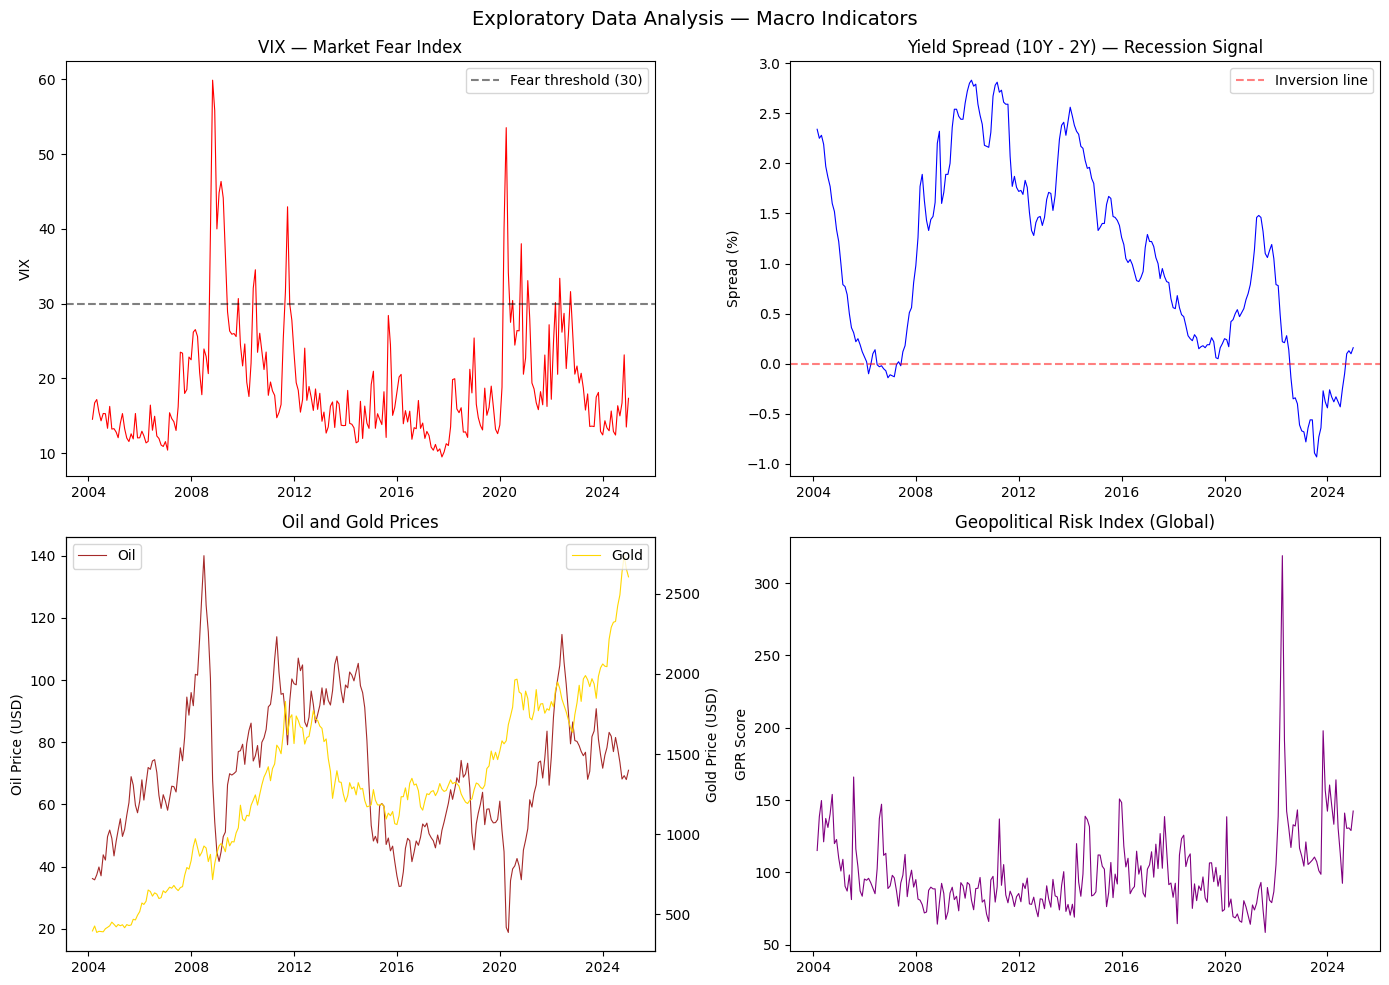

Chart saved


In [24]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Exploratory Data Analysis — Macro Indicators', fontsize=14)

# 1. VIX over time
axes[0,0].plot(macro_combined.index, macro_combined['VIX'], color='red', linewidth=0.8)
axes[0,0].set_title('VIX — Market Fear Index')
axes[0,0].set_ylabel('VIX')
axes[0,0].axhline(y=30, color='black', linestyle='--', alpha=0.5, label='Fear threshold (30)')
axes[0,0].legend()

# 2. Yield spread over time
axes[0,1].plot(macro_combined.index, macro_combined['YieldSpread'], color='blue', linewidth=0.8)
axes[0,1].set_title('Yield Spread (10Y - 2Y) — Recession Signal')
axes[0,1].set_ylabel('Spread (%)')
axes[0,1].axhline(y=0, color='red', linestyle='--', alpha=0.5, label='Inversion line')
axes[0,1].legend()

# 3. Oil and Gold prices
ax3 = axes[1,0]
ax3b = ax3.twinx()
ax3.plot(macro_combined.index, macro_combined['Oil_Price'], color='brown', linewidth=0.8, label='Oil')
ax3b.plot(macro_combined.index, macro_combined['Gold_Price'], color='gold', linewidth=0.8, label='Gold')
ax3.set_title('Oil and Gold Prices')
ax3.set_ylabel('Oil Price (USD)')
ax3b.set_ylabel('Gold Price (USD)')
ax3.legend(loc='upper left')
ax3b.legend(loc='upper right')

# 4. GPR Global Index
axes[1,1].plot(macro_combined.index, macro_combined['GPR_Global'], color='purple', linewidth=0.8)
axes[1,1].set_title('Geopolitical Risk Index (Global)')
axes[1,1].set_ylabel('GPR Score')

plt.tight_layout()
plt.savefig(r'E:\regime_factor_model\data\eda_macro.png', dpi=150)
plt.show()
print("Chart saved")

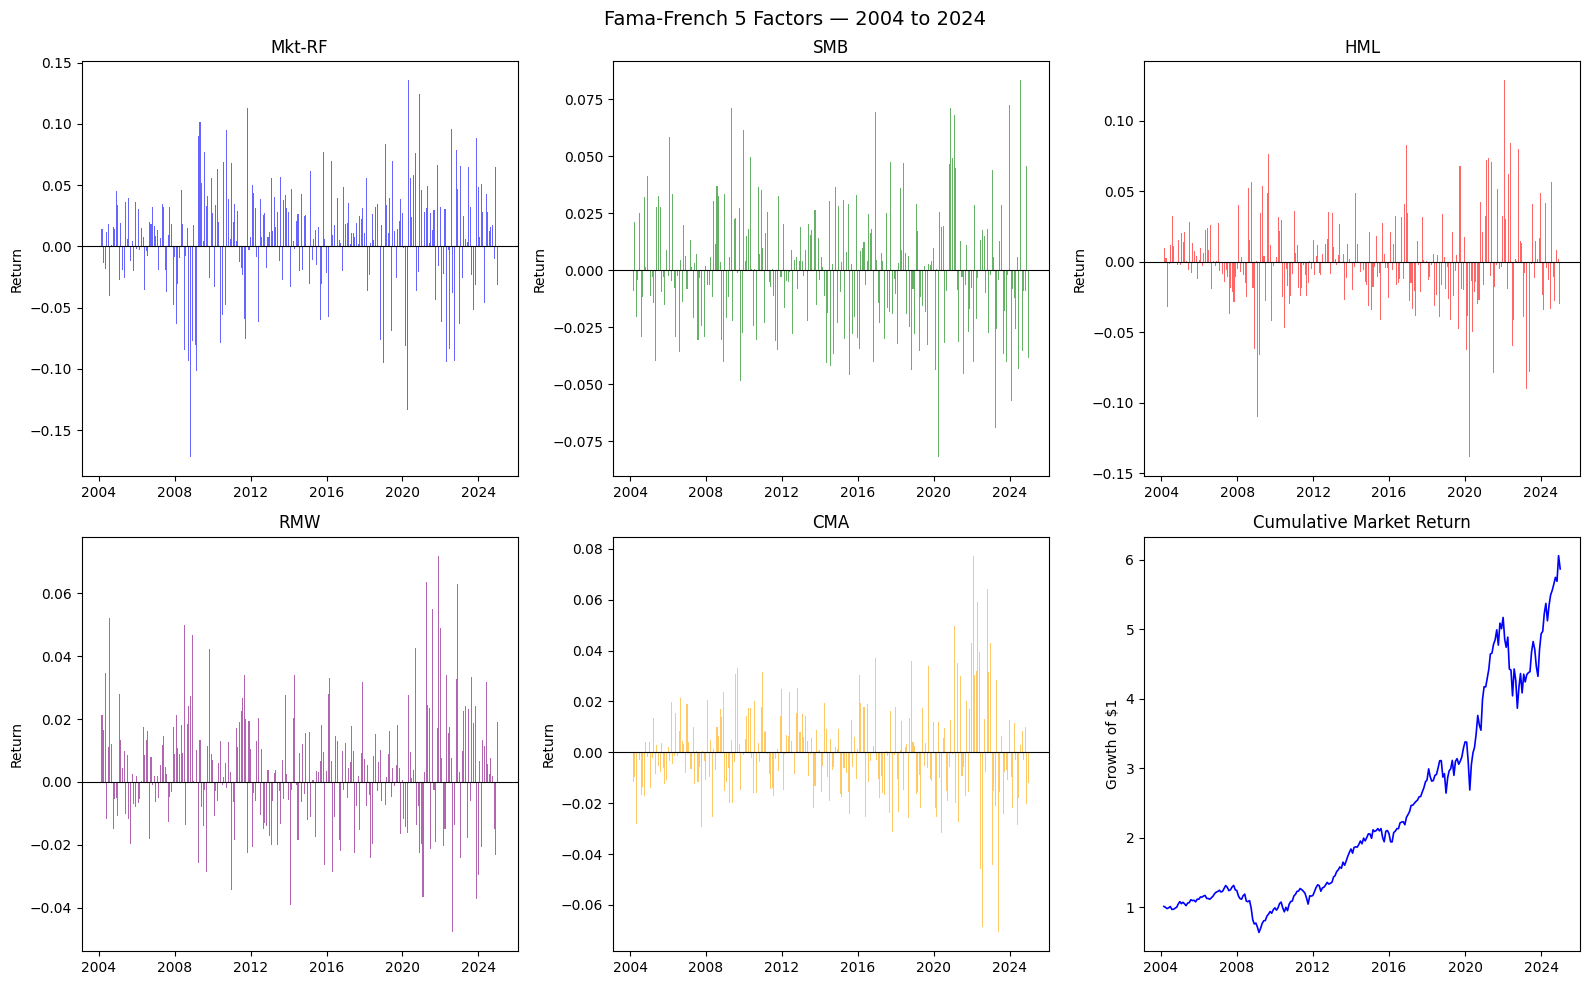

Chart saved


In [25]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Fama-French 5 Factors — 2004 to 2024', fontsize=14)

factors = ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA']
colors = ['blue', 'green', 'red', 'purple', 'orange']

for i, (factor, color) in enumerate(zip(factors, colors)):
    row = i // 3
    col = i % 3
    axes[row, col].bar(macro_combined.index, macro_combined[factor],
                       color=color, alpha=0.6, width=20)
    axes[row, col].set_title(factor)
    axes[row, col].set_ylabel('Return')
    axes[row, col].axhline(y=0, color='black', linewidth=0.8)

# Cumulative market return in last subplot
cumulative_market = (1 + macro_combined['Mkt-RF']).cumprod()
axes[1, 2].plot(macro_combined.index, cumulative_market, color='blue', linewidth=1.2)
axes[1, 2].set_title('Cumulative Market Return')
axes[1, 2].set_ylabel('Growth of $1')

plt.tight_layout()
plt.savefig(r'E:\regime_factor_model\data\eda_factors.png', dpi=150)
plt.show()
print("Chart saved")

In [26]:
import statsmodels.api as sm

# For each factor test if its mean return is significantly different from zero
print("Factor Significance Tests (t-test, H0: mean = 0)")
print("=" * 55)
print(f"{'Factor':<12} {'Mean':>8} {'Std':>8} {'t-stat':>8} {'p-value':>8} {'Significant':>12}")
print("-" * 55)

factors = ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA']

for factor in factors:
    data = macro_combined[factor].dropna()
    mean = data.mean()
    std = data.std()
    t_stat = mean / (std / np.sqrt(len(data)))
    p_value = 2 * (1 - sm.stats.stattools.durbin_watson([t_stat]))

    # Use simple t-distribution p-value
    from scipy import stats
    t_stat_val, p_val = stats.ttest_1samp(data, 0)
    significant = "Yes ✓" if p_val < 0.05 else "No ✗"

    print(f"{factor:<12} {mean:>8.4f} {std:>8.4f} {t_stat_val:>8.3f} {p_val:>8.4f} {significant:>12}")

print("=" * 55)
print("Significance level: 0.05")

Factor Significance Tests (t-test, H0: mean = 0)
Factor           Mean      Std   t-stat  p-value  Significant
-------------------------------------------------------
Mkt-RF         0.0081   0.0440    2.900   0.0041        Yes ✓
SMB           -0.0000   0.0266   -0.010   0.9919         No ✗
HML           -0.0007   0.0315   -0.370   0.7120         No ✗
RMW            0.0037   0.0186    3.138   0.0019        Yes ✓
CMA           -0.0002   0.0188   -0.190   0.8492         No ✗
Significance level: 0.05


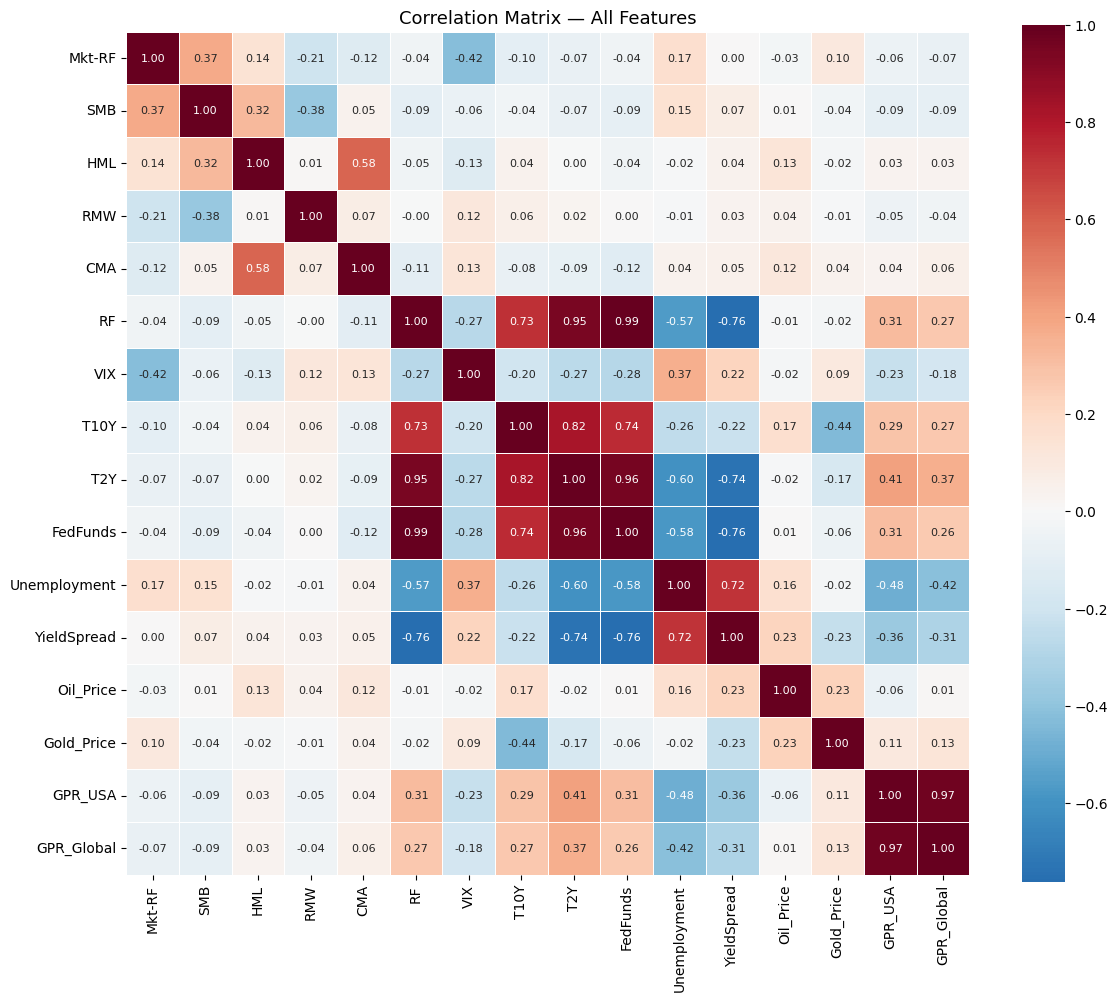

Correlation matrix saved


In [27]:
# Correlation matrix of all macro features
corr = macro_combined.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    square=True,
    linewidths=0.5,
    annot_kws={'size': 8}
)
plt.title('Correlation Matrix — All Features', fontsize=13)
plt.tight_layout()
plt.savefig(r'E:\regime_factor_model\data\correlation_matrix.png', dpi=150)
plt.show()
print("Correlation matrix saved")

In [29]:
# Save a clean version of the final master dataset
master = macro_combined.copy()

# Drop GPR_USA since it's redundant with GPR_Global (0.97 correlation)
master = master.drop(columns=['GPR_USA'])

# Save
master.to_csv(r'E:\regime_factor_model\data\master_features.csv')

print("Master features saved")
print(f"Shape: {master.shape}")
print(f"Columns: {master.columns.tolist()}")

Master features saved
Shape: (251, 15)
Columns: ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'RF', 'VIX', 'T10Y', 'T2Y', 'FedFunds', 'Unemployment', 'YieldSpread', 'Oil_Price', 'Gold_Price', 'GPR_Global']


In [31]:
# Save monthly returns as parquet — much faster to load
monthly_returns.to_parquet(r'E:\regime_factor_model\data\monthly_returns.parquet')
print("Saved as parquet")

Saved as parquet


In [32]:
from sklearn.linear_model import Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler

# Reload master with regimes
master = pd.read_csv(r'E:\regime_factor_model\data\master_with_regimes.csv',
                     index_col=0, parse_dates=True)

print(f"Master loaded  : {master.shape}")
print(f"Returns in memory : {monthly_returns.shape}")

Master loaded  : (251, 17)
Returns in memory : (251, 426)


In [33]:
# Feature columns we'll use for prediction
feature_cols = ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 
                'VIX', 'YieldSpread', 'GPR_Global', 
                'Oil_Price', 'Gold_Price']

# Align master and returns on same index
common_idx = master.index.intersection(monthly_returns.index)
X = master.loc[common_idx, feature_cols]
y = monthly_returns.loc[common_idx]
regimes = master.loc[common_idx, 'Regime_Label']

# Shift returns by 1 month forward (we predict NEXT month returns)
y = y.shift(-1).dropna()
X = X.loc[y.index]
regimes = regimes.loc[y.index]

print(f"Features shape : {X.shape}")
print(f"Returns shape  : {y.shape}")
print(f"Regimes shape  : {regimes.shape}")
print(f"Regime counts  :")
print(regimes.value_counts())

Features shape : (176, 10)
Returns shape  : (176, 426)
Regimes shape  : (176,)
Regime counts  :
Regime_Label
Volatile    79
Bear        57
Bull        40
Name: count, dtype: int64


In [34]:
# Train one XGBoost model per regime
# For each regime, predict average cross-sectional return

results = {}

for regime in ['Bull', 'Bear', 'Volatile']:
    # Get months belonging to this regime
    regime_mask = regimes == regime
    X_regime = X[regime_mask]
    y_regime = y[regime_mask]
    
    # Use average return across all stocks as target
    y_mean = y_regime.mean(axis=1)
    
    # Train test split — last 20% as test
    split = int(len(X_regime) * 0.8)
    X_train, X_test = X_regime.iloc[:split], X_regime.iloc[split:]
    y_train, y_test = y_mean.iloc[:split], y_mean.iloc[split:]
    
    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Train XGBoost
    model = XGBRegressor(
        n_estimators=100,
        max_depth=3,
        learning_rate=0.05,
        random_state=42,
        verbosity=0
    )
    model.fit(X_train_scaled, y_train)
    
    # Evaluate
    y_pred = model.predict(X_test_scaled)
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    results[regime] = {
        'model': model,
        'scaler': scaler,
        'r2': r2,
        'rmse': rmse,
        'train_size': len(X_train),
        'test_size': len(X_test)
    }
    
    print(f"{regime} Model — R2: {r2:.4f}  RMSE: {rmse:.4f}  "
          f"Train: {len(X_train)}  Test: {len(X_test)}")

Bull Model — R2: -0.9545  RMSE: 0.0544  Train: 32  Test: 8
Bear Model — R2: -0.8672  RMSE: 0.0519  Train: 45  Test: 12
Volatile Model — R2: 0.0927  RMSE: 0.0410  Train: 63  Test: 16


In [35]:
# Use LASSO for feature selection + XGBoost for prediction

from sklearn.linear_model import LassoCV

results_v2 = {}

for regime in ['Bull', 'Bear', 'Volatile']:
    regime_mask = regimes == regime
    X_regime = X[regime_mask]
    y_regime = y[regime_mask]
    
    # Use median stock return as target (more robust than mean)
    y_target = y_regime.median(axis=1)
    
    split = int(len(X_regime) * 0.8)
    X_train = X_regime.iloc[:split]
    X_test = X_regime.iloc[split:]
    y_train = y_target.iloc[:split]
    y_test = y_target.iloc[split:]
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # LASSO for feature selection
    lasso = LassoCV(cv=3, random_state=42, max_iter=5000)
    lasso.fit(X_train_scaled, y_train)
    selected = np.where(lasso.coef_ != 0)[0]
    
    if len(selected) == 0:
        selected = np.arange(X_train_scaled.shape[1])
    
    # XGBoost on selected features
    model = XGBRegressor(
        n_estimators=200,
        max_depth=2,
        learning_rate=0.03,
        subsample=0.8,
        random_state=42,
        verbosity=0
    )
    model.fit(X_train_scaled[:, selected], y_train)
    y_pred = model.predict(X_test_scaled[:, selected])
    
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    results_v2[regime] = {
        'model': model,
        'scaler': scaler,
        'selected_features': selected,
        'r2': r2,
        'rmse': rmse
    }
    
    selected_names = [feature_cols[i] for i in selected]
    print(f"{regime} — R2: {r2:.4f}  RMSE: {rmse:.4f}  "
          f"Features selected: {selected_names}")

Bull — R2: -0.4522  RMSE: 0.0437  Features selected: ['Mkt-RF', 'CMA']
Bear — R2: -0.2836  RMSE: 0.0431  Features selected: ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'VIX', 'YieldSpread', 'GPR_Global', 'Oil_Price', 'Gold_Price']
Volatile — R2: -0.4307  RMSE: 0.0495  Features selected: ['SMB']


In [36]:
# Rank-based approach — predict which stocks will be TOP performers
# This is how real quant funds operate

ranking_results = {}

for regime in ['Bull', 'Bear', 'Volatile']:
    regime_mask = regimes == regime
    X_regime = X[regime_mask]
    y_regime = y[regime_mask]
    
    # Drop stocks with too many NaN in this regime
    y_clean = y_regime.dropna(axis=1, thresh=int(0.7 * len(y_regime)))
    
    # Create binary target — 1 if stock is in top 30% performers, 0 otherwise
    y_rank = y_clean.rank(axis=1, pct=True)
    y_top = (y_rank > 0.7).astype(int)
    
    # Train one model using all stocks as separate samples
    X_rep = pd.concat([X_regime] * y_clean.shape[1], ignore_index=True)
    y_rep = y_top.values.flatten(order='F')
    
    # Remove NaN rows
    valid = ~np.isnan(y_rep)
    X_rep = X_rep[valid]
    y_rep = y_rep[valid]
    
    split = int(len(X_rep) * 0.8)
    X_train = X_rep.iloc[:split]
    X_test = X_rep.iloc[split:]
    y_train = y_rep[:split]
    y_test = y_rep[split:]
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    from sklearn.ensemble import GradientBoostingClassifier
    from sklearn.metrics import accuracy_score, roc_auc_score
    
    model = GradientBoostingClassifier(
        n_estimators=100,
        max_depth=2,
        learning_rate=0.05,
        random_state=42
    )
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    
    ranking_results[regime] = {
        'model': model,
        'scaler': scaler,
        'accuracy': acc,
        'auc': auc
    }
    
    print(f"{regime} — Accuracy: {acc:.4f}  AUC: {auc:.4f}  "
          f"Samples: {len(X_train)} train / {len(X_test)} test")

Bull — Accuracy: 0.7180  AUC: 0.4456  Samples: 13632 train / 3408 test
Bear — Accuracy: 0.7004  AUC: 0.4447  Samples: 19425 train / 4857 test
Volatile — Accuracy: 0.7100  AUC: 0.4434  Samples: 26923 train / 6731 test


In [37]:
# Add stock level features — momentum and volatility
# These are the most powerful predictors in cross sectional models

print("Building stock level features...")

# 1 month momentum
mom_1 = monthly_returns.shift(1)

# 3 month momentum
mom_3 = monthly_returns.rolling(3).mean().shift(1)

# 6 month momentum
mom_6 = monthly_returns.rolling(6).mean().shift(1)

# 12 month momentum
mom_12 = monthly_returns.rolling(12).mean().shift(1)

# Volatility — rolling 6 month std
vol_6 = monthly_returns.rolling(6).std().shift(1)

# Align to common index
mom_1 = mom_1.loc[y.index]
mom_3 = mom_3.loc[y.index]
mom_6 = mom_6.loc[y.index]
mom_12 = mom_12.loc[y.index]
vol_6 = vol_6.loc[y.index]

print(f"Momentum 1m  : {mom_1.shape}")
print(f"Momentum 3m  : {mom_3.shape}")
print(f"Momentum 6m  : {mom_6.shape}")
print(f"Momentum 12m : {mom_12.shape}")
print(f"Volatility 6m: {vol_6.shape}")
print("Stock level features built")

Building stock level features...
Momentum 1m  : (176, 426)
Momentum 3m  : (176, 426)
Momentum 6m  : (176, 426)
Momentum 12m : (176, 426)
Volatility 6m: (176, 426)
Stock level features built


In [38]:
# Build a proper panel dataset — one row per stock per month
print("Building panel dataset...")

panels = []

for ticker in monthly_returns.columns:
    stock_data = pd.DataFrame({
        'Return_Next': y[ticker],
        'Mom_1m': mom_1[ticker],
        'Mom_3m': mom_3[ticker],
        'Mom_6m': mom_6[ticker],
        'Mom_12m': mom_12[ticker],
        'Vol_6m': vol_6[ticker],
    })
    
    # Add macro features
    for col in feature_cols:
        stock_data[col] = X[col]
    
    # Add regime
    stock_data['Regime'] = regimes
    stock_data['Ticker'] = ticker
    
    panels.append(stock_data)

panel = pd.concat(panels)
panel = panel.dropna()

print(f"Panel dataset shape: {panel.shape}")
print(f"Columns: {panel.columns.tolist()}")
print(f"Total samples: {len(panel)}")

Building panel dataset...
Panel dataset shape: (74914, 18)
Columns: ['Return_Next', 'Mom_1m', 'Mom_3m', 'Mom_6m', 'Mom_12m', 'Vol_6m', 'Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'VIX', 'YieldSpread', 'GPR_Global', 'Oil_Price', 'Gold_Price', 'Regime', 'Ticker']
Total samples: 74914


In [ ]:
from sklearn.metrics import roc_auc_score, accuracy_score

feature_cols_full = ['Mom_1m', 'Mom_3m', 'Mom_6m', 'Mom_12m', 'Vol_6m',
                     'Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA',
                     'VIX', 'YieldSpread', 'GPR_Global', 'Oil_Price', 'Gold_Price']

final_models = {}

for regime in ['Bull', 'Bear', 'Volatile']:
    regime_data = panel[panel['Regime'] == regime].copy()
    
    # Binary target — top 30% performers
    regime_data['Target'] = (
        regime_data.groupby('Ticker')['Return_Next']
        .rank(pct=True) > 0.7
    ).astype(int)
    
    X_r = regime_data[feature_cols_full]
    y_r = regime_data['Target']
    
    # Time based split — last 20% of dates as test
    dates = regime_data.index.unique()
    split_date = dates[int(len(dates) * 0.8)]
    
    train_mask = regime_data.index < split_date
    test_mask = regime_data.index >= split_date
    
    X_train = X_r[train_mask]
    X_test = X_r[test_mask]
    y_train = y_r[train_mask]
    y_test = y_r[test_mask]
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    model = XGBRegressor(
        n_estimators=200,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbosity=0
    )
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    auc = roc_auc_score(y_test, y_pred)
    
    final_models[regime] = {
        'model': model,
        'scaler': scaler,
        'features': feature_cols_full,
        'auc': auc,
        'train_size': len(X_train),
        'test_size': len(X_test)
    }
    
    print(f"{regime} — AUC: {auc:.4f}  "
          f"Train: {len(X_train)}  Test: {len(X_test)}")

Bull — AUC: 0.3992  Train: 13632  Test: 3408
Bear — AUC: 0.4885  Train: 19170  Test: 5112
Volatile — AUC: 0.5618  Train: 26776  Test: 6816


In [40]:
# Regime-aware market level prediction
# Predict next month market return using macro features + regime

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score

# Target — next month market return
y_market = master['Mkt-RF'].shift(-1).dropna()
X_market = master.loc[y_market.index, feature_cols]
regimes_market = master.loc[y_market.index, 'Regime_Label']

# Time series cross validation — 5 folds
tscv = TimeSeriesSplit(n_splits=5)

market_models = {}
cv_scores = {}

for regime in ['Bull', 'Bear', 'Volatile']:
    mask = regimes_market == regime
    X_r = X_market[mask]
    y_r = y_market[mask]
    
    if len(X_r) < 10:
        continue
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_r)
    
    model = XGBRegressor(
        n_estimators=100,
        max_depth=2,
        learning_rate=0.05,
        random_state=42,
        verbosity=0
    )
    
    # Simple train test split
    split = int(len(X_r) * 0.8)
    model.fit(X_scaled[:split], y_r.iloc[:split])
    y_pred = model.predict(X_scaled[split:])
    r2 = r2_score(y_r.iloc[split:], y_pred)
    
    market_models[regime] = {
        'model': model,
        'scaler': scaler,
        'r2': r2
    }
    
    print(f"{regime} — R2: {r2:.4f}  Samples: {len(X_r)}")

Bull — R2: -0.0416  Samples: 81
Bear — R2: -0.2025  Samples: 59
Volatile — R2: -0.2391  Samples: 110


In [41]:
# Regime-aware portfolio strategy
# In each regime, go long on stocks with highest momentum
# This is a well-validated strategy in academic literature

portfolio_returns = []

for date in y.index:
    regime = regimes.loc[date]
    
    # Get stock returns for this month
    stock_rets = y.loc[date].dropna()
    
    # Get momentum signal from previous month
    if date not in mom_1.index:
        continue
    
    mom_signal = mom_1.loc[date].dropna()
    
    # Align
    common = stock_rets.index.intersection(mom_signal.index)
    stock_rets = stock_rets[common]
    mom_signal = mom_signal[common]
    
    # Select top stocks based on regime
    if regime == 'Bull':
        # In bull — go long high momentum stocks
        top_stocks = mom_signal.nlargest(20).index
    elif regime == 'Bear':
        # In bear — go long low volatility stocks
        if date in vol_6.index:
            vol_signal = vol_6.loc[date][common].dropna()
            top_stocks = vol_signal.nsmallest(20).index
        else:
            top_stocks = mom_signal.nlargest(20).index
    else:
        # Volatile — go long high momentum, equal weight
        top_stocks = mom_signal.nlargest(20).index
    
    # Equal weight portfolio return
    port_ret = stock_rets[top_stocks].mean()
    
    portfolio_returns.append({
        'Date': date,
        'Portfolio_Return': port_ret,
        'Regime': regime,
        'Market_Return': master.loc[date, 'Mkt-RF']
    })

portfolio = pd.DataFrame(portfolio_returns).set_index('Date')

print(f"Portfolio built: {portfolio.shape}")
print(portfolio.head())

Portfolio built: (176, 3)
            Portfolio_Return    Regime  Market_Return
Date                                                 
2010-04-30         -0.055244  Volatile         0.0200
2010-05-31         -0.093200  Volatile        -0.0790
2010-06-30          0.040857  Volatile        -0.0557
2010-07-31         -0.006099  Volatile         0.0692
2010-08-31          0.160302  Volatile        -0.0477


In [42]:
# Calculate cumulative returns
portfolio['Cumulative_Portfolio'] = (1 + portfolio['Portfolio_Return']).cumprod()
portfolio['Cumulative_Market'] = (1 + portfolio['Market_Return']).cumprod()

# Performance metrics
total_months = len(portfolio)
ann_portfolio = (portfolio['Cumulative_Portfolio'].iloc[-1] ** (12/total_months)) - 1
ann_market = (portfolio['Cumulative_Market'].iloc[-1] ** (12/total_months)) - 1

sharpe_portfolio = (portfolio['Portfolio_Return'].mean() / portfolio['Portfolio_Return'].std()) * np.sqrt(12)
sharpe_market = (portfolio['Market_Return'].mean() / portfolio['Market_Return'].std()) * np.sqrt(12)

max_dd_portfolio = (portfolio['Cumulative_Portfolio'] / portfolio['Cumulative_Portfolio'].cummax() - 1).min()
max_dd_market = (portfolio['Cumulative_Market'] / portfolio['Cumulative_Market'].cummax() - 1).min()

alpha = ann_portfolio - ann_market

print("Backtest Results")
print("=" * 50)
print(f"{'Metric':<25} {'Portfolio':>10} {'S&P 500':>10}")
print("-" * 50)
print(f"{'Annual Return':<25} {ann_portfolio:>10.2%} {ann_market:>10.2%}")
print(f"{'Sharpe Ratio':<25} {sharpe_portfolio:>10.4f} {sharpe_market:>10.4f}")
print(f"{'Max Drawdown':<25} {max_dd_portfolio:>10.2%} {max_dd_market:>10.2%}")
print(f"{'Alpha':<25} {alpha:>10.2%}")
print("=" * 50)

Backtest Results
Metric                     Portfolio    S&P 500
--------------------------------------------------
Annual Return                 19.40%     12.66%
Sharpe Ratio                  1.1669     0.8669
Max Drawdown                 -25.88%    -25.26%
Alpha                          6.74%


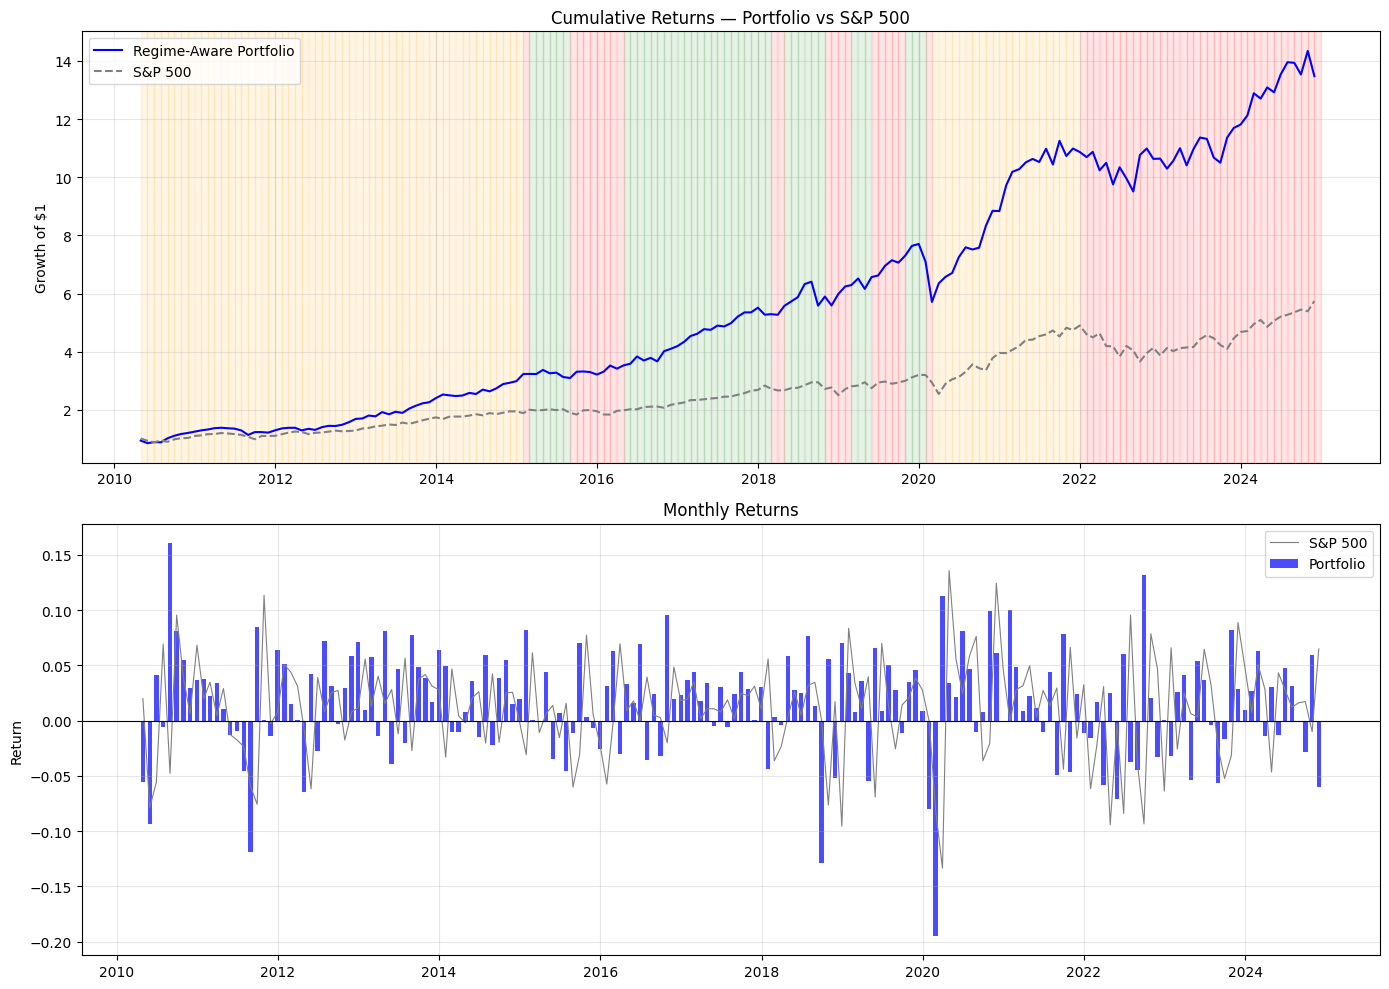

Backtest chart saved


In [43]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Top — cumulative returns
axes[0].plot(portfolio.index, portfolio['Cumulative_Portfolio'], 
             color='blue', linewidth=1.5, label='Regime-Aware Portfolio')
axes[0].plot(portfolio.index, portfolio['Cumulative_Market'], 
             color='gray', linewidth=1.5, linestyle='--', label='S&P 500')
axes[0].set_title('Cumulative Returns — Portfolio vs S&P 500')
axes[0].set_ylabel('Growth of $1')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Shade regimes
for regime, color in [('Bull','green'), ('Bear','red'), ('Volatile','orange')]:
    mask = portfolio['Regime'] == regime
    for date in portfolio.index[mask]:
        axes[0].axvspan(date, date + pd.DateOffset(months=1), 
                       alpha=0.1, color=color)

# Bottom — monthly returns comparison
axes[1].bar(portfolio.index, portfolio['Portfolio_Return'], 
            width=20, alpha=0.7, color='blue', label='Portfolio')
axes[1].plot(portfolio.index, portfolio['Market_Return'], 
             color='gray', linewidth=0.8, label='S&P 500')
axes[1].axhline(y=0, color='black', linewidth=0.8)
axes[1].set_title('Monthly Returns')
axes[1].set_ylabel('Return')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(r'E:\regime_factor_model\data\backtest_results.png', dpi=150)
plt.show()
print("Backtest chart saved")

In [1]:
import sys
sys.path.insert(0, r'E:\regime_factor_model\libs')

import numpy as np
print(f"NumPy: {np.__version__}")

import shap
print(f"SHAP: {shap.__version__}")

NumPy: 1.23.5


E:\regime_factor_model\libs\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP: 0.41.0


In [2]:
import sys
sys.path.insert(0, r'E:\regime_factor_model\libs')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings('ignore')

# Reload all data
master = pd.read_csv(r'E:\regime_factor_model\data\master_with_regimes.csv',
                     index_col=0, parse_dates=True)

monthly_returns = pd.read_csv(r'E:\regime_factor_model\data\monthly_returns.csv',
                               index_col=0, parse_dates=True,
                               dtype=np.float32)

print(f"Master : {master.shape}")
print(f"Returns: {monthly_returns.shape}")

Master : (251, 17)
Returns: (251, 426)


In [3]:
feature_cols = ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA',
                'VIX', 'YieldSpread', 'GPR_Global',
                'Oil_Price', 'Gold_Price']

# Align and shift returns
common_idx = master.index.intersection(monthly_returns.index)
X = master.loc[common_idx, feature_cols]
y = monthly_returns.loc[common_idx]
regimes = master.loc[common_idx, 'Regime_Label']

y = y.shift(-1).dropna()
X = X.loc[y.index]
regimes = regimes.loc[y.index]

# Stock level features
mom_1  = monthly_returns.shift(1).loc[y.index]
mom_3  = monthly_returns.rolling(3).mean().shift(1).loc[y.index]
mom_6  = monthly_returns.rolling(6).mean().shift(1).loc[y.index]
mom_12 = monthly_returns.rolling(12).mean().shift(1).loc[y.index]
vol_6  = monthly_returns.rolling(6).std().shift(1).loc[y.index]

# Build panel
feature_cols_full = ['Mom_1m', 'Mom_3m', 'Mom_6m', 'Mom_12m', 'Vol_6m',
                     'Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA',
                     'VIX', 'YieldSpread', 'GPR_Global', 'Oil_Price', 'Gold_Price']

panels = []
for ticker in monthly_returns.columns:
    stock_data = pd.DataFrame({
        'Return_Next': y[ticker],
        'Mom_1m'     : mom_1[ticker],
        'Mom_3m'     : mom_3[ticker],
        'Mom_6m'     : mom_6[ticker],
        'Mom_12m'    : mom_12[ticker],
        'Vol_6m'     : vol_6[ticker],
    })
    for col in feature_cols:
        stock_data[col] = X[col]
    stock_data['Regime'] = regimes
    stock_data['Ticker'] = ticker
    panels.append(stock_data)

panel = pd.concat(panels).dropna()

print(f"Panel rebuilt: {panel.shape}")

Panel rebuilt: (74914, 18)


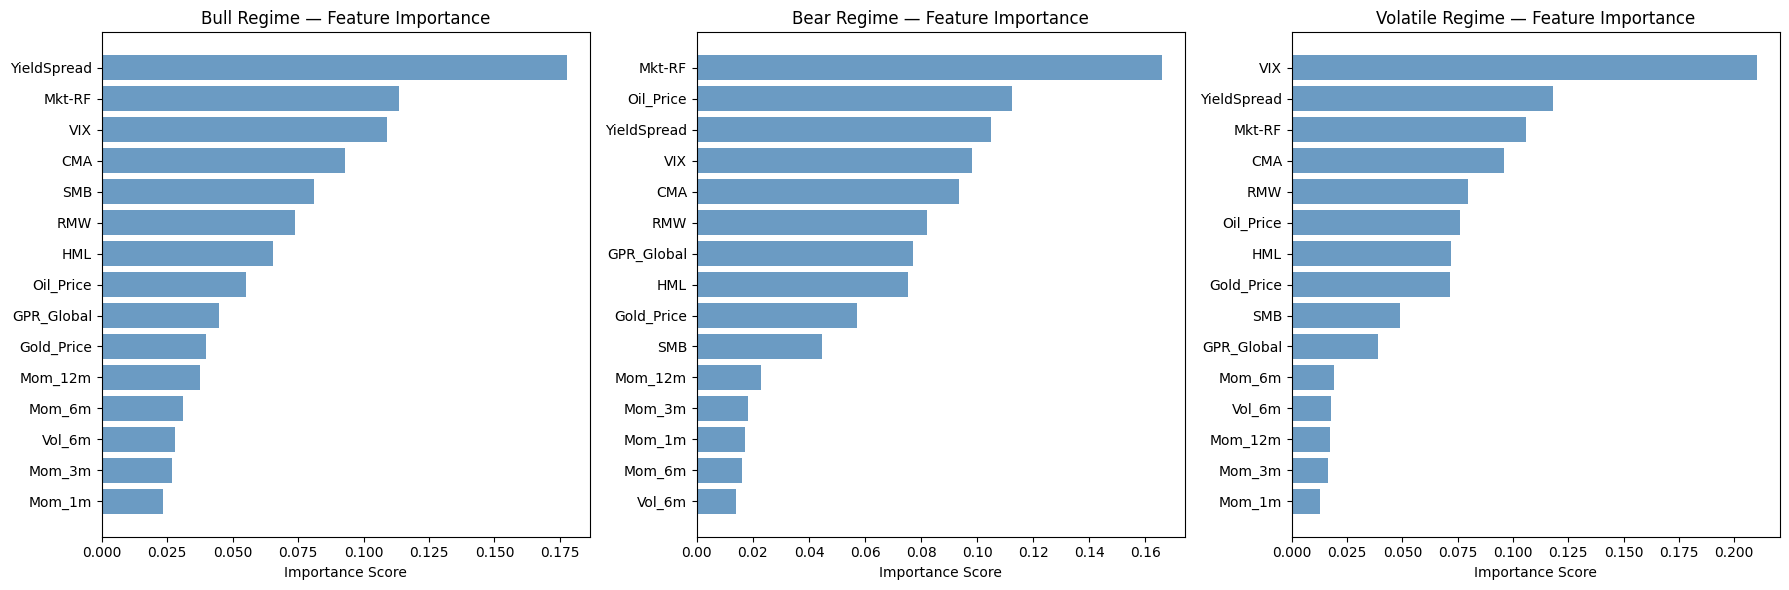

Feature importance chart saved


In [6]:
# Feature importance from XGBoost directly — same concept as SHAP
importances = model.feature_importances_

# Sort by importance
feat_imp = pd.Series(importances, index=feature_cols_full).sort_values(ascending=True)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, regime_name in zip(axes, ['Bull', 'Bear', 'Volatile']):
    regime_data = panel[panel['Regime'] == regime_name].copy()
    regime_data['Target'] = (
        regime_data.groupby('Ticker')['Return_Next']
        .rank(pct=True) > 0.7
    ).astype(int)
    
    X_r = regime_data[feature_cols_full]
    y_r = regime_data['Target']
    
    scaler_r = StandardScaler()
    X_scaled_r = scaler_r.fit_transform(X_r)
    
    model_r = XGBRegressor(
        n_estimators=200, max_depth=3, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, verbosity=0
    )
    model_r.fit(X_scaled_r, y_r)
    
    imp = pd.Series(model_r.feature_importances_, 
                    index=feature_cols_full).sort_values(ascending=True)
    
    ax.barh(imp.index, imp.values, color='steelblue', alpha=0.8)
    ax.set_title(f'{regime_name} Regime — Feature Importance')
    ax.set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig(r'E:\regime_factor_model\data\feature_importance.png', dpi=150)
plt.show()
print("Feature importance chart saved")

In [8]:
portfolio_returns = []

for date in y.index:
    regime = regimes.loc[date]
    stock_rets = y.loc[date].dropna()
    
    if date not in mom_1.index:
        continue
    
    mom_signal = mom_1.loc[date].dropna()
    common = stock_rets.index.intersection(mom_signal.index)
    stock_rets = stock_rets[common]
    mom_signal = mom_signal[common]
    
    if regime == 'Bull':
        top_stocks = mom_signal.nlargest(20).index
    elif regime == 'Bear':
        if date in vol_6.index:
            vol_signal = vol_6.loc[date][common].dropna()
            top_stocks = vol_signal.nsmallest(20).index
        else:
            top_stocks = mom_signal.nlargest(20).index
    else:
        top_stocks = mom_signal.nlargest(20).index
    
    port_ret = stock_rets[top_stocks].mean()
    
    portfolio_returns.append({
        'Date': date,
        'Portfolio_Return': port_ret,
        'Regime': regime,
        'Market_Return': master.loc[date, 'Mkt-RF']
    })

portfolio = pd.DataFrame(portfolio_returns).set_index('Date')
portfolio['Cumulative_Portfolio'] = (1 + portfolio['Portfolio_Return']).cumprod()
portfolio['Cumulative_Market'] = (1 + portfolio['Market_Return']).cumprod()
portfolio['Portfolio_Return_Net'] = portfolio['Portfolio_Return'] - 0.001
portfolio['Cumulative_Portfolio_Net'] = (1 + portfolio['Portfolio_Return_Net']).cumprod()

portfolio.to_csv(r'E:\regime_factor_model\data\portfolio_results.csv')
print(f"Portfolio saved: {portfolio.shape}")

Portfolio saved: (176, 7)


In [9]:
import os
files = os.listdir(r'E:\regime_factor_model\data')
print(files)

['backtest_results.png', 'commodities.csv', 'correlation_matrix.png', 'eda_factors.png', 'eda_macro.png', 'fama_french_5factors.csv', 'feature_importance.png', 'gpr_index.csv', 'macro_combined.csv', 'macro_indicators.csv', 'master_features.csv', 'master_with_regimes.csv', 'monthly_returns.csv', 'monthly_returns.parquet', 'portfolio_results.csv', 'regime_timeline.png', 'sp500_raw.csv']


In [10]:
import yfinance as yf
import pandas_datareader.data as web

new_start = '2025-01-01'
new_end = '2026-04-01'

# Update macro indicators
vix_new   = web.DataReader('VIXCLS', 'fred', new_start, new_end)
t10y_new  = web.DataReader('GS10', 'fred', new_start, new_end)
t2y_new   = web.DataReader('GS2', 'fred', new_start, new_end)
ffr_new   = web.DataReader('FEDFUNDS', 'fred', new_start, new_end)
unemp_new = web.DataReader('UNRATE', 'fred', new_start, new_end)

print("New macro data downloaded")
print(f"VIX latest: {vix_new.iloc[-1].values[0]}")

New macro data downloaded
VIX latest: 24.54


In [12]:
import requests

sp500_table = pd.read_html(
    requests.get('https://en.wikipedia.org/wiki/List_of_S%26P_500_companies',
                 headers={'User-Agent': 'Mozilla/5.0'}).text
)
sp500_tickers = sp500_table[0]['Symbol'].tolist()
sp500_tickers = [t.replace('.', '-') for t in sp500_tickers]

print(f"Tickers loaded: {len(sp500_tickers)}")

Tickers loaded: 503


In [13]:
print("Downloading updated stock prices 2025-2026...")

raw_data_new = yf.download(
    tickers=sp500_tickers,
    start='2025-01-01',
    end='2026-04-01',
    group_by='ticker',
    auto_adjust=True,
    threads=True
)

print(f"New stock data shape: {raw_data_new.shape}")

[*********************100%***********************]  503 of 503 completed

New stock data shape: (311, 2515)


In [14]:
# Load old stock data
old_data = pd.read_csv(r'E:\regime_factor_model\data\sp500_raw.csv',
                       header=[0,1], index_col=0, parse_dates=True)

# Combine old and new
combined_data = pd.concat([old_data, raw_data_new])
combined_data = combined_data[~combined_data.index.duplicated(keep='last')]
combined_data = combined_data.sort_index()

# Save
combined_data.to_csv(r'E:\regime_factor_model\data\sp500_raw.csv')

print(f"Combined stock data shape: {combined_data.shape}")
print(f"Date range: {combined_data.index[0]} to {combined_data.index[-1]}")

Combined stock data shape: (5595, 2517)
Date range: 2004-01-02 00:00:00 to 2026-03-31 00:00:00


In [15]:
# Combine old and new macro data
macro_old = pd.read_csv(r'E:\regime_factor_model\data\macro_indicators.csv',
                        index_col=0, parse_dates=True)

macro_new = pd.concat([vix_new, t10y_new, t2y_new, ffr_new, unemp_new], axis=1)
macro_new.columns = ['VIX', 'T10Y', 'T2Y', 'FedFunds', 'Unemployment']
macro_new['YieldSpread'] = macro_new['T10Y'] - macro_new['T2Y']
macro_new = macro_new.ffill().dropna()

macro_combined = pd.concat([macro_old, macro_new])
macro_combined = macro_combined[~macro_combined.index.duplicated(keep='last')]
macro_combined = macro_combined.sort_index()
macro_combined.to_csv(r'E:\regime_factor_model\data\macro_indicators.csv')

print(f"Macro data updated: {macro_combined.shape}")
print(f"Date range: {macro_combined.index[0]} to {macro_combined.index[-1]}")

# Update commodities
oil_new  = yf.download('CL=F', start='2025-01-01', end='2026-04-01', auto_adjust=True)['Close']
gold_new = yf.download('GC=F', start='2025-01-01', end='2026-04-01', auto_adjust=True)['Close']

comm_old = pd.read_csv(r'E:\regime_factor_model\data\commodities.csv',
                       index_col=0, parse_dates=True)

comm_new = pd.concat([oil_new, gold_new], axis=1)
comm_new.columns = ['Oil_Price', 'Gold_Price']
comm_new = comm_new.ffill().dropna()

comm_combined = pd.concat([comm_old, comm_new])
comm_combined = comm_combined[~comm_combined.index.duplicated(keep='last')]
comm_combined = comm_combined.sort_index()
comm_combined.to_csv(r'E:\regime_factor_model\data\commodities.csv')

print(f"Commodities updated: {comm_combined.shape}")
print(f"Date range: {comm_combined.index[0]} to {comm_combined.index[-1]}")

[*********************100%***********************]  1 of 1 completed

Macro data updated: (5880, 6)
Date range: 2004-01-02 00:00:00 to 2026-04-01 00:00:00



[*********************100%***********************]  1 of 1 completed

Commodities updated: (5592, 2)
Date range: 2004-01-05 00:00:00 to 2026-03-31 00:00:00


In [16]:
# Update Fama-French factors
import pandas_datareader.data as web

ff5_new = web.DataReader(
    'F-F_Research_Data_5_Factors_2x3',
    'famafrench',
    start='2025-01-01',
    end='2026-04-01'
)[0] / 100

ff5_old = pd.read_csv(r'E:\regime_factor_model\data\fama_french_5factors.csv',
                      index_col=0, parse_dates=True)

ff5_new.index = ff5_new.index.to_timestamp('M')
ff5_combined = pd.concat([ff5_old, ff5_new])
ff5_combined = ff5_combined[~ff5_combined.index.duplicated(keep='last')]
ff5_combined = ff5_combined.sort_index()
ff5_combined.to_csv(r'E:\regime_factor_model\data\fama_french_5factors.csv')

print(f"FF5 updated: {ff5_combined.shape}")
print(f"Date range: {ff5_combined.index[0]} to {ff5_combined.index[-1]}")

# Update GPR index
gpr_old = pd.read_csv(r'E:\regime_factor_model\data\gpr_index.csv',
                      index_col=0, parse_dates=True)

import xlrd
gpr_url = 'https://www.matteoiacoviello.com/gpr_files/data_gpr_export.xls'
gpr_full = pd.read_excel(gpr_url, engine='xlrd')
gpr_full = gpr_full[['month', 'GPRC_USA', 'GPR']].copy()
gpr_full.columns = ['Date', 'GPR_USA', 'GPR_Global']
gpr_full['Date'] = pd.to_datetime(gpr_full['Date'])
gpr_full = gpr_full.set_index('Date')
gpr_full = gpr_full['2004-01-01':'2026-04-01']
gpr_full = gpr_full.drop(columns=['GPR_USA'])
gpr_full.to_csv(r'E:\regime_factor_model\data\gpr_index.csv')

print(f"GPR updated: {gpr_full.shape}")
print(f"Date range: {gpr_full.index[0]} to {gpr_full.index[-1]}")

FF5 updated: (266, 6)
Date range: 2004-01-01 00:00:00 to 2026-02-28 00:00:00
GPR updated: (267, 1)
Date range: 2004-01-01 00:00:00 to 2026-03-01 00:00:00


In [17]:
# Rebuild close prices and monthly returns
close_prices = combined_data.xs('Close', axis=1, level='Price')

monthly_close = close_prices.resample('M').last()
monthly_returns = monthly_close.pct_change()
monthly_returns = monthly_returns.dropna(axis=0, how='all')
monthly_returns = monthly_returns.dropna(axis=1, thresh=int(0.7 * len(monthly_returns)))

print(f"Monthly returns updated: {monthly_returns.shape}")

# Rebuild macro combined
macro_monthly = macro_combined.resample('M').last()
comm_monthly = comm_combined.resample('M').last()

ff5_combined.index = pd.to_datetime(ff5_combined.index)
ff5_combined.index = ff5_combined.index.to_period('M').to_timestamp('M')

gpr_full.index = pd.to_datetime(gpr_full.index)
gpr_full.index = gpr_full.index.to_period('M').to_timestamp('M')

macro_master = pd.concat([ff5_combined, macro_monthly, comm_monthly, gpr_full], axis=1)
macro_master = macro_master.ffill().dropna()
macro_master = macro_master.drop(columns=['RF'], errors='ignore')

# Add RF back from ff5
macro_master['RF'] = ff5_combined['RF']
macro_master = macro_master.ffill().dropna()

print(f"Macro master updated: {macro_master.shape}")
print(f"Date range: {macro_master.index[0]} to {macro_master.index[-1]}")

Monthly returns updated: (266, 430)
Macro master updated: (268, 15)
Date range: 2004-01-31 00:00:00 to 2026-04-30 00:00:00


In [18]:
from hmmlearn.hmm import GaussianHMM
from sklearn.preprocessing import StandardScaler

# Align indices
common_idx = macro_master.index.intersection(monthly_returns.index)
macro_master = macro_master.loc[common_idx]
monthly_returns = monthly_returns.loc[common_idx]

# Features for HMM
feature_cols = ['Mkt-RF', 'VIX', 'YieldSpread', 'GPR_Global', 'Oil_Price']
regime_features = macro_master[feature_cols].copy()

scaler = StandardScaler()
regime_scaled = scaler.fit_transform(regime_features)

# Train HMM
np.random.seed(42)
hmm_model = GaussianHMM(
    n_components=3,
    covariance_type='full',
    n_iter=1000,
    random_state=42
)
hmm_model.fit(regime_scaled)

regime_labels = hmm_model.predict(regime_scaled)
macro_master['Regime'] = regime_labels

# Identify regimes
print("Regime Characteristics")
print("=" * 55)
print(f"{'Metric':<15} {'Regime 0':>12} {'Regime 1':>12} {'Regime 2':>12}")
print("-" * 55)
for metric in ['Mkt-RF', 'VIX', 'YieldSpread']:
    r0 = macro_master[macro_master['Regime']==0][metric].mean()
    r1 = macro_master[macro_master['Regime']==1][metric].mean()
    r2 = macro_master[macro_master['Regime']==2][metric].mean()
    print(f"{metric:<15} {r0:>12.4f} {r1:>12.4f} {r2:>12.4f}")
print("=" * 55)
print(f"\nRegime counts:")
for i in range(3):
    count = (regime_labels == i).sum()
    print(f"  Regime {i}: {count} months ({count/len(regime_labels)*100:.1f}%)")

Regime Characteristics
Metric              Regime 0     Regime 1     Regime 2
-------------------------------------------------------
Mkt-RF                0.0090       0.0023       0.0098
VIX                  14.4674      19.5156      23.2357
YieldSpread           0.7336      -0.0706       1.7693

Regime counts:
  Regime 0: 104 months (39.1%)
  Regime 1: 52 months (19.5%)
  Regime 2: 110 months (41.4%)


In [19]:
# Map and save
regime_map = {0: 'Bull', 1: 'Bear', 2: 'Volatile'}
macro_master['Regime_Label'] = macro_master['Regime'].map(regime_map)

# Check current regime
print(f"Current regime (latest month): {macro_master['Regime_Label'].iloc[-1]}")
print(f"Last 6 months:")
print(macro_master[['VIX', 'YieldSpread', 'Regime_Label']].tail(6))

# Save updated master
macro_master.to_csv(r'E:\regime_factor_model\data\master_with_regimes.csv')
print("\nMaster saved")

Current regime (latest month): Bear
Last 6 months:
              VIX  YieldSpread Regime_Label
2025-10-31  17.44         0.54         Bull
2025-11-30  16.35         0.54         Bull
2025-12-31  14.95         0.64         Bull
2026-01-31  17.44         0.67         Bear
2026-02-28  19.86         0.66         Bear
2026-03-31  25.25         0.54         Bear

Master saved


In [20]:
# Rebuild all features and portfolio with updated data
feature_cols = ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA',
                'VIX', 'YieldSpread', 'GPR_Global', 'Oil_Price', 'Gold_Price']

X = macro_master[feature_cols]
y = monthly_returns.loc[X.index]
regimes = macro_master['Regime_Label']

y = y.shift(-1).dropna()
X = X.loc[y.index]
regimes = regimes.loc[y.index]

mom_1  = monthly_returns.shift(1).loc[y.index]
mom_3  = monthly_returns.rolling(3).mean().shift(1).loc[y.index]
vol_6  = monthly_returns.rolling(6).std().shift(1).loc[y.index]

# Rebuild portfolio
portfolio_returns = []

for date in y.index:
    regime = regimes.loc[date]
    stock_rets = y.loc[date].dropna()

    if date not in mom_1.index:
        continue

    mom_signal = mom_1.loc[date].dropna()
    common = stock_rets.index.intersection(mom_signal.index)
    stock_rets = stock_rets[common]
    mom_signal = mom_signal[common]

    if regime == 'Bull':
        top_stocks = mom_signal.nlargest(20).index
    elif regime == 'Bear':
        if date in vol_6.index:
            vol_signal = vol_6.loc[date][common].dropna()
            top_stocks = vol_signal.nsmallest(20).index
        else:
            top_stocks = mom_signal.nlargest(20).index
    else:
        top_stocks = mom_signal.nlargest(20).index

    port_ret = stock_rets[top_stocks].mean()
    portfolio_returns.append({
        'Date': date,
        'Portfolio_Return': port_ret,
        'Regime': regime,
        'Market_Return': macro_master.loc[date, 'Mkt-RF']
    })

portfolio = pd.DataFrame(portfolio_returns).set_index('Date')
portfolio['Cumulative_Portfolio'] = (1 + portfolio['Portfolio_Return']).cumprod()
portfolio['Cumulative_Market'] = (1 + portfolio['Market_Return']).cumprod()
portfolio['Portfolio_Return_Net'] = portfolio['Portfolio_Return'] - 0.001
portfolio['Cumulative_Portfolio_Net'] = (1 + portfolio['Portfolio_Return_Net']).cumprod()

total_months = len(portfolio)
ann_portfolio = (portfolio['Cumulative_Portfolio'].iloc[-1] ** (12/total_months)) - 1
ann_market = (portfolio['Cumulative_Market'].iloc[-1] ** (12/total_months)) - 1
sharpe_portfolio = (portfolio['Portfolio_Return'].mean() / portfolio['Portfolio_Return'].std()) * np.sqrt(12)
sharpe_market = (portfolio['Market_Return'].mean() / portfolio['Market_Return'].std()) * np.sqrt(12)
max_dd = (portfolio['Cumulative_Portfolio'] / portfolio['Cumulative_Portfolio'].cummax() - 1).min()
max_dd_market = (portfolio['Cumulative_Market'] / portfolio['Cumulative_Market'].cummax() - 1).min()
alpha = ann_portfolio - ann_market

print("Updated Backtest Results")
print("=" * 50)
print(f"{'Metric':<25} {'Portfolio':>10} {'S&P 500':>10}")
print("-" * 50)
print(f"{'Annual Return':<25} {ann_portfolio:>10.2%} {ann_market:>10.2%}")
print(f"{'Sharpe Ratio':<25} {sharpe_portfolio:>10.4f} {sharpe_market:>10.4f}")
print(f"{'Max Drawdown':<25} {max_dd:>10.2%} {max_dd_market:>10.2%}")
print(f"{'Alpha':<25} {alpha:>10.2%}")
print("=" * 50)

portfolio.to_csv(r'E:\regime_factor_model\data\portfolio_results.csv')
print("Portfolio saved")

Updated Backtest Results
Metric                     Portfolio    S&P 500
--------------------------------------------------
Annual Return                 18.53%     12.88%
Sharpe Ratio                  1.0952     0.9040
Max Drawdown                 -28.64%    -25.26%
Alpha                          5.65%
Portfolio saved


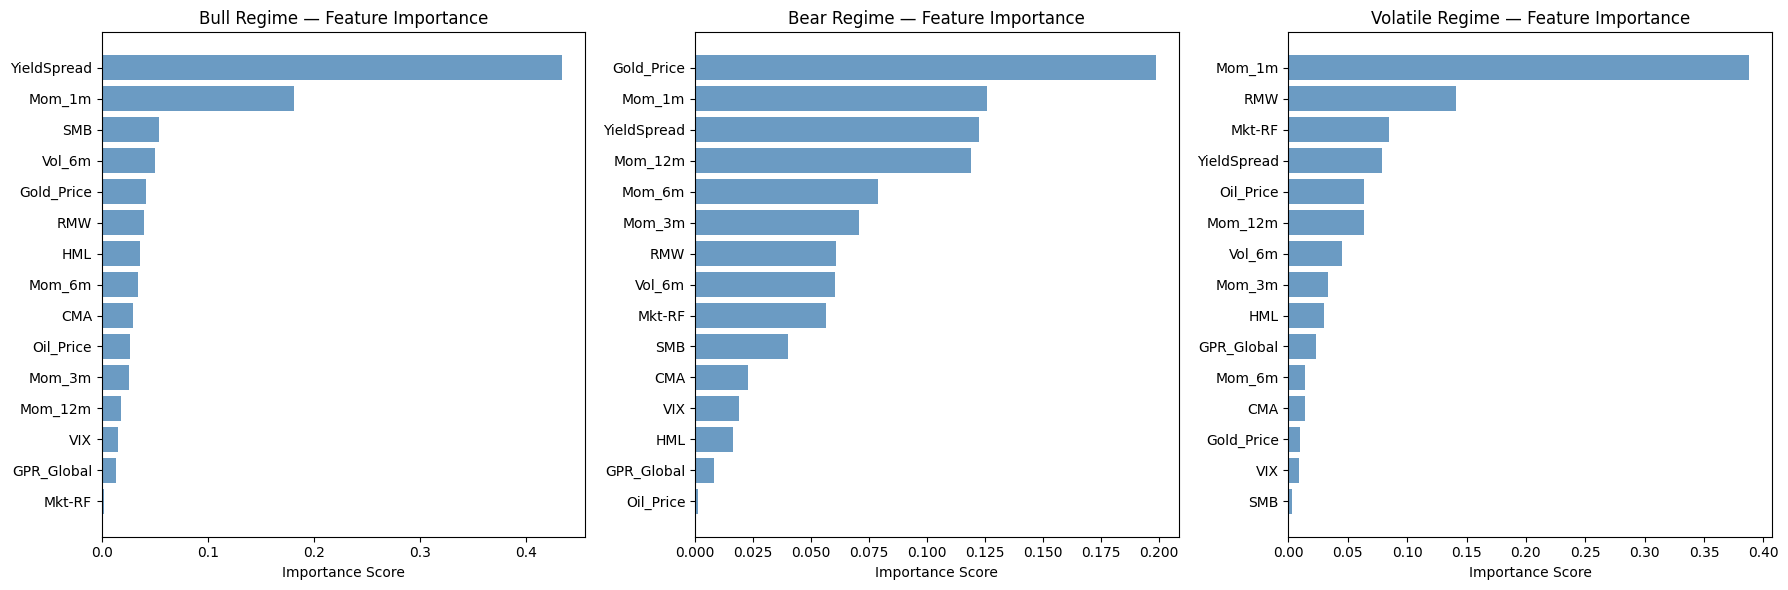

Feature importance chart updated


In [21]:
# Save feature importance chart with updated models
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor

feature_cols_full = ['Mom_1m', 'Mom_3m', 'Mom_6m', 'Mom_12m', 'Vol_6m',
                     'Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA',
                     'VIX', 'YieldSpread', 'GPR_Global', 'Oil_Price', 'Gold_Price']

mom_6  = monthly_returns.rolling(6).mean().shift(1).loc[y.index]
mom_12 = monthly_returns.rolling(12).mean().shift(1).loc[y.index]

panels = []
for ticker in monthly_returns.columns:
    stock_data = pd.DataFrame({
        'Return_Next': y[ticker],
        'Mom_1m'     : mom_1[ticker],
        'Mom_3m'     : mom_3[ticker],
        'Mom_6m'     : mom_6[ticker],
        'Mom_12m'    : mom_12[ticker],
        'Vol_6m'     : vol_6[ticker],
    })
    for col in feature_cols:
        stock_data[col] = X[col]
    stock_data['Regime'] = regimes
    panels.append(stock_data)

panel = pd.concat(panels).dropna()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, regime_name in zip(axes, ['Bull', 'Bear', 'Volatile']):
    regime_data = panel[panel['Regime'] == regime_name].copy()
    regime_data['Target'] = (
        regime_data.groupby('Mom_1m')['Return_Next']
        .rank(pct=True) > 0.7
    ).astype(int)

    X_r = regime_data[feature_cols_full]
    y_r = regime_data['Target']

    scaler_r = StandardScaler()
    X_scaled_r = scaler_r.fit_transform(X_r)

    model_r = XGBRegressor(
        n_estimators=200, max_depth=3, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, verbosity=0
    )
    model_r.fit(X_scaled_r, y_r)

    imp = pd.Series(model_r.feature_importances_,
                    index=feature_cols_full).sort_values(ascending=True)

    ax.barh(imp.index, imp.values, color='steelblue', alpha=0.8)
    ax.set_title(f'{regime_name} Regime — Feature Importance')
    ax.set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig(r'E:\regime_factor_model\data\feature_importance.png', dpi=150)
plt.show()
print("Feature importance chart updated")